In [3]:
import zipfile
import os

zip_path = "Flickr8k.zip"
extract_path = "Flickr8k"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done!")

Extraction Done!


In [5]:
import os
os.listdir("Flickr8k")

['captions.txt', '.ipynb_checkpoints', 'Images']

# 1. Loading Captions

In [18]:
captions_dict = {}

with open("Flickr8k/captions.txt", 'r') as file:
    next(file)  # skip header if present
    
    for line in file:
        line = line.strip()
        if len(line) == 0:
            continue
        
        img, caption = line.split(',', 1)   # split only once
        
        # add start and end tokens
        caption = "startseq " + caption.lower() + " endseq"
        
        if img not in captions_dict:
            captions_dict[img] = []
        
        captions_dict[img].append(caption)

In [20]:
image_name = "1000268201_693b08cb0e.jpg"

print(captions_dict[image_name])

['startseq a child in a pink dress is climbing up a set of stairs in an entry way . endseq', 'startseq a girl going into a wooden building . endseq', 'startseq a little girl climbing into a wooden playhouse . endseq', 'startseq a little girl climbing the stairs to her playhouse . endseq', 'startseq a little girl in a pink dress going into a wooden cabin . endseq']


Captions:
- startseq a child in a pink dress is climbing up a set of stairs in an entry way . endseq
- startseq a girl going into a wooden building . endseq
- startseq a little girl climbing into a wooden playhouse . endseq
- startseq a little girl climbing the stairs to her playhouse . endseq
- startseq a little girl in a pink dress going into a wooden cabin . endseq


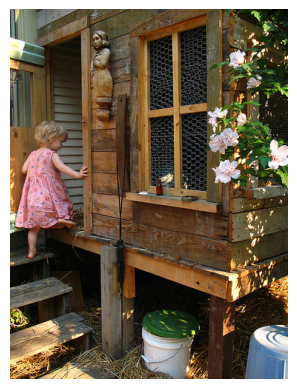

In [21]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "Flickr8k/Images/1000268201_693b08cb0e.jpg"

img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')

print("Captions:")
for cap in captions_dict[image_name]:
    print("-", cap)

# 2. Text Cleaning

In [24]:
import string

def clean_text(captions_dict):
    table = str.maketrans('', '', string.punctuation)
    
    for key, captions in captions_dict.items():
        for i in range(len(captions)):
            caption = captions[i]
            
            caption = caption.lower()
            caption = caption.translate(table)
            caption = caption.split()
            
            # remove short words
            caption = [word for word in caption if len(word) > 1]
            
            caption = ' '.join(caption)
            captions[i] = caption

In [25]:
clean_text(captions_dict)

# 3. Tokenization

In [26]:
all_captions = []
for captions in captions_dict.values():
    all_captions.extend(captions)

In [27]:
from tensorflow.keras.preprocessing.text import Tokenizer

# create tokenizer
tokenizer = Tokenizer()

# learn vocabulary
tokenizer.fit_on_texts(all_captions)

# total words
vocab_size = len(tokenizer.word_index) + 1

print("Vocab Size:", vocab_size)

2026-06-08 20:09:39.354625: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-08 20:09:41.270820: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-08 20:09:47.952670: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Vocab Size: 8811


In [29]:
seq = tokenizer.texts_to_sequences(["startseq a dog running endseq"])
print(seq)

[[1, 8, 31, 2]]


# 4. Padding

In [32]:
max_length = max(len(c.split()) for c in all_captions)
print("Max Length:", max_length)

Max Length: 34


In [34]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

seq = tokenizer.texts_to_sequences(["startseq dog running endseq"])[0]

padded = pad_sequences([seq], maxlen=max_length)

print(padded)

[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  1  8 31  2]]


# 5. Image feature Extraction

In [35]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model

base_model = ResNet50(weights='imagenet')

# remove last layer
model_cnn = Model(inputs=base_model.input,
                  outputs=base_model.layers[-2].output)

I0000 00:00:1780949432.638612     649 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [37]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os

In [38]:
features = {}

image_list = os.listdir("Flickr8k/Images")[:500]   

for img_name in image_list:
    
    path = "Flickr8k/Images/" + img_name
    
    # load image
    img = load_img(path, target_size=(224,224))
    
    # convert to array
    img = img_to_array(img)
    
    # preprocess for ResNet
    img = preprocess_input(img)
    
    # add batch dimension
    img = np.expand_dims(img, axis=0)
    
    # extract features
    feature = model_cnn.predict(img, verbose=0)
    
    features[img_name] = feature

2026-06-08 20:17:14.778778: I external/local_xla/xla/service/service.cc:163] XLA service 0x71e278002ac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-08 20:17:14.778858: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-06-08 20:17:14.996865: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-08 20:17:16.852635: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600
I0000 00:00:1780949843.508927    1560 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [40]:
print(len(features))
print(features[image_list[0]].shape)

500
(1, 2048)


# 6. Creating Training Data

In [42]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [43]:
X1 = []   # Image Features
X2 = []   # Input Sequences
y = []    # Next Word

In [44]:
# Loop through all images and captions
for img, caps in captions_dict.items():

    # Skip images whose features were not extracted
    if img not in features:
        continue

    # Process each caption
    for cap in caps:

        # Convert caption to sequence of integers
        seq = tokenizer.texts_to_sequences([cap])[0]

        # Create training samples
        for i in range(1, len(seq)):

            # Input sequence
            in_seq = seq[:i]

            # Output word
            out_seq = seq[i]

            # Pad input sequence
            in_seq = pad_sequences(
                [in_seq],
                maxlen=max_length,
                padding='post'
            )[0]

            # One-hot encode output word
            out_seq = to_categorical(
                out_seq,
                num_classes=vocab_size
            )

            # Store data
            X1.append(features[img][0])
            X2.append(in_seq)
            y.append(out_seq)

# Convert to NumPy arrays
X1 = np.array(X1)
X2 = np.array(X2)
y = np.array(y)

In [51]:
print("X1 shape:", X1.shape)
print("X2 shape:", X2.shape)
print("y shape :", y.shape)

X1 shape: (25288, 2048)
X2 shape: (25288, 34)
y shape : (25288, 8811)


In [52]:
print(vocab_size)
print(max_length)

8811
34


# 7. Building the model

In [53]:
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, add
from tensorflow.keras.models import Model

In [64]:
# Image Input Branch
input1 = Input(shape=(2048,))

fe1 = Dense(256, activation='relu')(input1)

In [70]:
# Caption Input Branch
input2 = Input(shape=(max_length,))

se1 = Embedding(
    input_dim=vocab_size,
    output_dim=256,
    mask_zero=True
)(input2)

se2 = LSTM(256)(se1)

In [71]:
# Combine Both Branches
decoder1 = add([fe1, se2])

decoder2 = Dense(256, activation='relu')(decoder1)

output = Dense(vocab_size, activation='softmax')(decoder2)


In [75]:
# Final Model
model = Model(
    inputs=[input1, input2],
    outputs=output
)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 34, 256)   │  2,255,616 │ input_layer_14[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_8         │ (None, 34)        │          0 │ input_layer_14[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │    524,544 │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ (None, 256)       │    525,312 │ embedding_8[0][0… │
│                     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256)       │          0 │ dense_8[0][0],    │
│                     │                   │            │ lstm_8[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256)       │     65,792 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 8811)      │  2,264,427 │ dense_13[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,635,691 (21.50 MB)

 Trainable params: 5,635,691 (21.50 MB)

 Non-trainable params: 0 (0.00 B)

# 8. Training the Model

In [76]:
history = model.fit(
    [X1, X2],
    y,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    verbose=1
)

Epoch 1/40
633/633 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.1471 - loss: 5.4927 - val_accuracy: 0.1858 - val_loss: 5.2583
Epoch 2/40
633/633 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.2163 - loss: 4.3314 - val_accuracy: 0.2019 - val_loss: 5.0488
Epoch 3/40
633/633 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.2746 - loss: 3.6746 - val_accuracy: 0.2139 - val_loss: 5.1208
Epoch 4/40
633/633 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.3155 - loss: 3.1684 - val_accuracy: 0.2212 - val_loss: 5.3188
Epoch 5/40
633/633 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.3617 - loss: 2.7593 - val_accuracy: 0.2137 - val_loss: 5.5919
Epoch 6/40
633/633 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.3965 - loss: 2.4098 - val_accuracy: 0.2177 - val_loss: 5.7726
Epoch 7/40
633/633 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.4346 - loss: 2.1244 - val_accuracy: 0.2125 - val_loss: 6.1009
Epoch 8/40
633/633 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - accuracy: 0.4756 - loss: 1.8767 - 

# 9. Generating Captions

In [78]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

In [81]:
def generate_caption(model, tokenizer, photo, max_length):

    in_text = "startseq"

    for i in range(max_length):

        # Convert text to sequence
        seq = tokenizer.texts_to_sequences([in_text])[0]

        # Pad sequence
        seq = pad_sequences(
            [seq],
            maxlen=max_length,
            padding='post'
        )

        # Predict next word
        yhat = model.predict(
            [photo, seq],
            verbose=0
        )

        # Get word with highest probability
        yhat = np.argmax(yhat)

        # Convert number back to word
        word = tokenizer.index_word.get(yhat)

        if word is None:
            break

        in_text += " " + word

        if word == "endseq":
            break

    return in_text

In [83]:
def clean_caption(caption):

    words = caption.split()

    words = [
        word for word in words
        if word not in ["startseq", "endseq"]
    ]

    return " ".join(words)

In [106]:
img_name = list(features.keys())[150]

In [107]:
photo = features[img_name]

In [108]:
caption = generate_caption(
    model,
    tokenizer,
    photo,
    max_length
)

print("Raw Caption:")
print(caption)

print("\nClean Caption:")
print(clean_caption(caption))

Raw Caption:
startseq man riding bicycle performs trick above dirt mound endseq

Clean Caption:
man riding bicycle performs trick above dirt mound


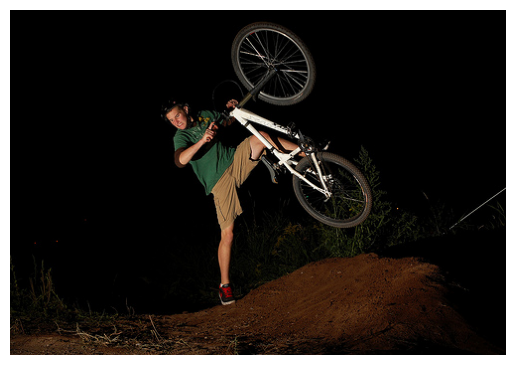

man riding bicycle performs trick above dirt mound


In [109]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "Flickr8k/Images/" + img_name

img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')
plt.show()

print(clean_caption(caption))

# 10. Testing

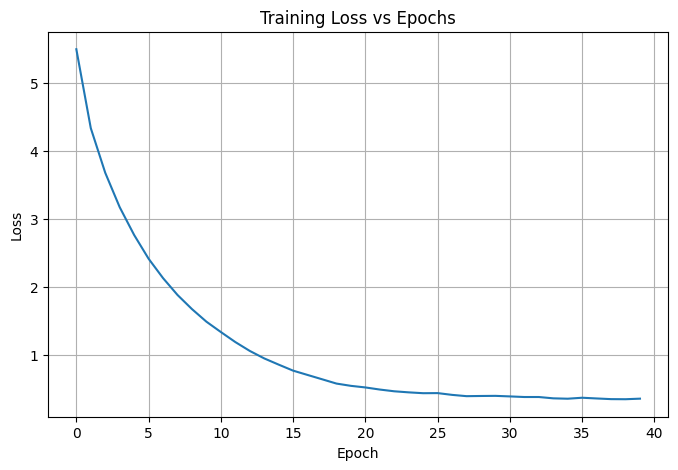

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

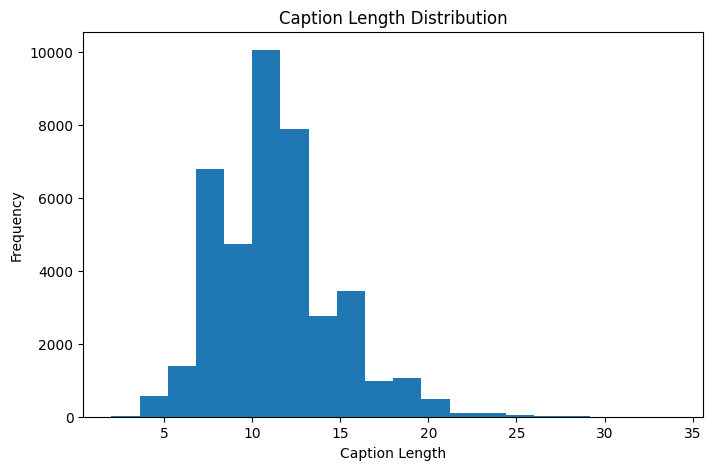

In [113]:
caption_lengths = [len(cap.split()) for cap in all_captions]

plt.figure(figsize=(8,5))
plt.hist(caption_lengths, bins=20)
plt.title("Caption Length Distribution")
plt.xlabel("Caption Length")
plt.ylabel("Frequency")
plt.show()

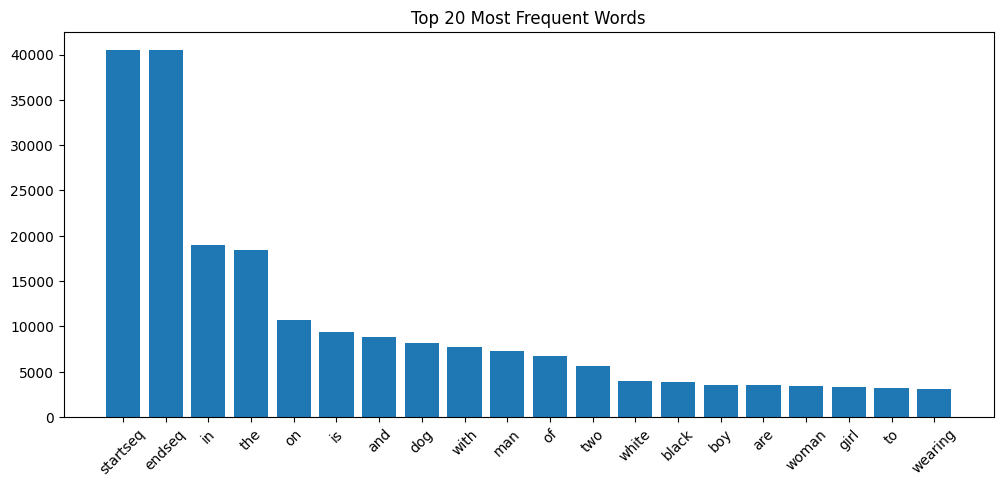

In [115]:
from collections import Counter

words = []

for caption in all_captions:
    words.extend(caption.split())

counter = Counter(words)

top_words = counter.most_common(20)

labels = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

plt.figure(figsize=(12,5))
plt.bar(labels, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

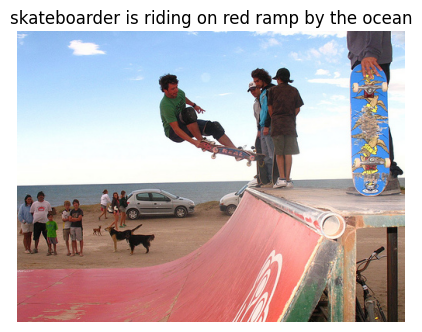

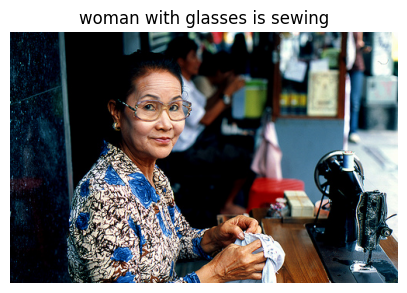

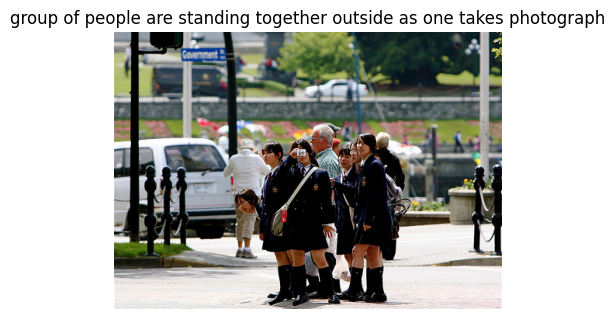

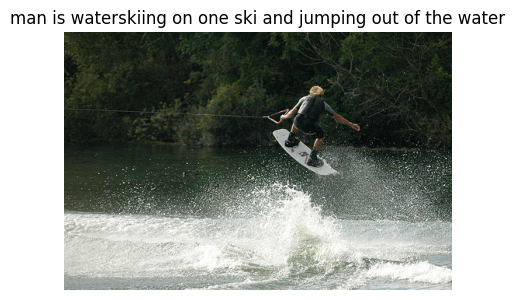

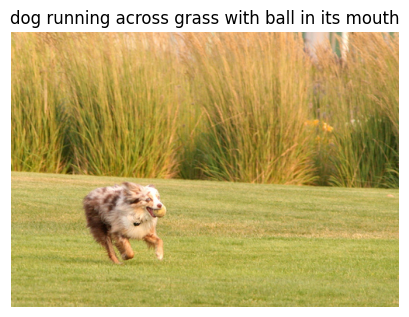

In [124]:
import random
from PIL import Image
import matplotlib.pyplot as plt

sample_images = random.sample(list(features.keys()), 5)

for img_name in sample_images:

    caption = generate_caption(
        model,
        tokenizer,
        features[img_name],
        max_length
    )

    img = Image.open("Flickr8k/Images/" + img_name)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(clean_caption(caption))
    plt.show()

In [125]:
model.save("image_caption_model_500img.keras")

In [126]:
import pickle

with open("tokenizer_500img.pkl", "wb") as f:
    pickle.dump(tokenizer, f)